In [49]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

IMG_SIZE = 64

train_folder = "anime_faces_split/train"
test_folder = "anime_faces_split/test"

In [58]:
def load_images(folder):

    images = []

    for filename in os.listdir(folder):

        path = os.path.join(folder, filename)

        try:
            img = load_img(path, target_size=(IMG_SIZE, IMG_SIZE))

            img = img_to_array(img)

            img = img / 255.0

            images.append(img)

        except:
            print("Erreur :", filename)

    return np.array(images)

In [59]:
x_train = load_images(train_folder)
x_test = load_images(test_folder)

print(x_train.shape)
print(x_test.shape)

(50852, 64, 64, 3)
(12713, 64, 64, 3)


In [60]:
print("Min/Max x_train:", x_train.min(), x_train.max())
print("Moyenne:", x_train.mean())
print("Shape:", x_train.shape)

Min/Max x_train: 0.0 1.0
Moyenne: 0.61539716
Shape: (50852, 64, 64, 3)


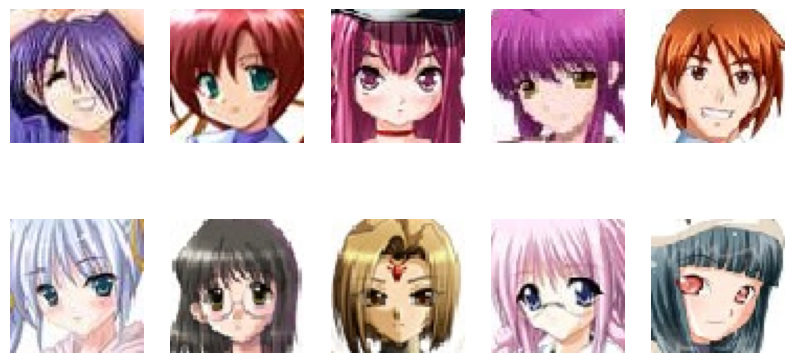

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.axis("off")

plt.show()

In [62]:
print("Min/Max x_train:", x_train.min(), x_train.max())
print("Moyenne:", x_train.mean())
print("Shape:", x_train.shape)

Min/Max x_train: 0.0 1.0
Moyenne: 0.61539716
Shape: (50852, 64, 64, 3)


In [63]:
print(x_train.shape)  

(50852, 64, 64, 3)


In [64]:
import numpy as np

noise_factor = 0.2

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

# Garder les valeurs entre 0 et 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

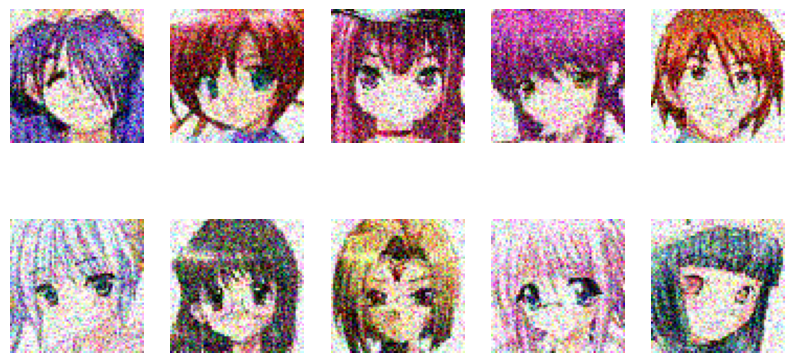

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train_noisy[i])
    plt.axis("off")

plt.show()

In [66]:
# Configurations principales de nos modèles
IMG_SIZE          = 64                # taille coté final d'une image en pixel (ici 28x28)
NB_EPOCHS_DENOISE = 10               # nombre epoch alogithme debruiter
BATCH_SIZE        = 128               # taille batch de traitement
SAV_MODEL_DENOISE = "denoiser.h5"     # sauvegarde du modele de debruitage

###### Encodeur

In [67]:
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D


# The encoding process
input_img =\
 Input(shape=(IMG_SIZE, IMG_SIZE, 3))  #SOLUTION

# Encoding #

# Conv1 #
x = Conv2D(\
           filters = 32, kernel_size = (3, 3), activation='relu', padding='same')(input_img)#SOLUTION
# kernel_size: Specifying the height and width of the 2D convolution window.
x = MaxPooling2D(\
                 pool_size = (2, 2), padding='same')(x)#SOLUTION

# Conv 2 #
x = Conv2D(\
           filters = 32,kernel_size = (3, 3), activation='relu', padding='same')(x)#SOLUTION
encoded = MaxPooling2D(\
                       pool_size = (2, 2), padding='same')(x)#SOLUTION

###### Decodeur

In [68]:
# DeConv1
x = Conv2D(\
           32, (3, 3), activation='relu', padding='same')(encoded)#SOLUTION
x = UpSampling2D(\
                 (2, 2))(x)#SOLUTION

# DeConv2
x = Conv2D(\
           32, (3, 3), activation='relu', padding='same')(x) #SOLUTION
x = UpSampling2D(\
                 (2, 2))(x)#SOLUTION

# Deconv3
decoded = Conv2D(3, (3, 3), activation=\
                 'sigmoid', padding='same')(x)#SOLUTION

###### Auto-encodeur

In [69]:
from tensorflow.keras.models import Model
# Declare the model
autoencoder = \
Model(input_img, decoded)#SOLUTION
autoencoder.compile(optimizer=\
                    'adam',#SOLUTION
                    loss=\
                    'mse')#SOLUTION
autoencoder.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 64, 64, 3)]       0         
                                                                 
 conv2d_7 (Conv2D)           (None, 64, 64, 32)        896       
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 32, 32, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_8 (Conv2D)           (None, 32, 32, 32)        9248      
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 16, 16, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_9 (Conv2D)           (None, 16, 16, 32)        9248

In [70]:
import tensorflow as tf 

# Train the model
history = autoencoder.fit(\
                          x_train_noisy, x_train,#SOLUTION
                epochs=10,#SOLUTION
                batch_size=BATCH_SIZE,#SOLUTION
                shuffle=\
                True,#SOLUTION
                validation_data=(\
                                 x_test_noisy, x_test),#SOLUTION
                callbacks=[tf.keras.callbacks.TensorBoard(log_dir='/tmp/tb', histogram_freq=0, write_graph=False)]
               )

Epoch 1/10
398/398 [==============================] - 136s 335ms/step - loss: 0.0214 - val_loss: 0.0151
Epoch 2/10
398/398 [==============================] - 127s 320ms/step - loss: 0.0142 - val_loss: 0.0134
Epoch 3/10
398/398 [==============================] - 137s 345ms/step - loss: 0.0131 - val_loss: 0.0126
Epoch 4/10
398/398 [==============================] - 121s 304ms/step - loss: 0.0123 - val_loss: 0.0118
Epoch 5/10
398/398 [==============================] - 128s 321ms/step - loss: 0.0114 - val_loss: 0.0110
Epoch 6/10
398/398 [==============================] - 122s 307ms/step - loss: 0.0108 - val_loss: 0.0106
Epoch 7/10
398/398 [==============================] - 116s 290ms/step - loss: 0.0103 - val_loss: 0.0102
Epoch 8/10
398/398 [==============================] - 113s 284ms/step - loss: 0.0100 - val_loss: 0.0098
Epoch 9/10
398/398 [==============================] - 116s 291ms/step - loss: 0.0097 - val_loss: 0.0098
Epoch 10/10
398/398 [==============================] - 112s 282m

In [71]:
# save the model
autoencoder.save("model_denoising.h5") #SOLUTION

c:\Users\gbencheikh\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
